In [1]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm




%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [9]:
session_path = '../data/to/to5/to5_06202024'
session = MPOptoClass(session_path)

THAL_depth_mask = session.mask_depths(greater=300, less=1000)
new_train = []
for idx in np.arange(len(THAL_depth_mask)):
    if THAL_depth_mask[idx] == True:
        new_train.append(session.RFA['train'][idx])
session.RFA['train'] = new_train
session.num_RFA = len(new_train)

love


In [10]:
nlags=20
binsize=5
pre=nlags*binsize
post=29
num_PCs=20
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
powers = session.getPowers(laser_bounds, num_powers=2, pre=pre, post=post)
high_laser_bounds = laser_bounds[powers==2, :]
climb_bounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)
climb_bounds = omitBoundInBounds(climb_bounds, ctrl_bounds)

In [33]:
X_laser, Y_laser, PCs_laser = session.generate_trainset(high_laser_bounds, binsize, nlags, num_PCs=20)
X_climb, Y_climb, PCs_climb = session.generate_trainset(climb_bounds, binsize, nlags, num_PCs=20)
h_laser = train_wiener_filter(X_laser, Y_laser, c=(2,5))
h_climb = train_wiener_filter(X_climb, Y_climb, c=(2,5))
X_test_climb, Y_test_climb = session.generate_testset(PCs_laser, climb_bounds, binsize, nlags, num_PCs)
X_test_laser, Y_test_laser = session.generate_testset(PCs_climb, high_laser_bounds, binsize, nlags, num_PCs)
cfa_mask, thal_mask = session.mask_input_region(X_laser, nlags, num_CFA=num_PCs)
X_cfa_laser = X_laser[:,cfa_mask]
X_cfa_climb = X_climb[:, cfa_mask]

bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too sma

In [35]:
h_cfa_climb = train_wiener_filter(X_cfa_climb, Y_climb, c=(2,5))

In [29]:
yhat_laser = test_wiener_filter(X_test_laser, h_climb)
print(weighted_r2(Y_test_laser, yhat_laser))

0.10947482715684748


In [30]:
yhat_climb = test_wiener_filter(X_test_climb, h_laser)
print(weighted_r2(Y_test_climb, yhat_climb))

0.20913890900428694


In [31]:
yhat_laser = test_wiener_filter(X_test_laser, h_laser)
print(weighted_r2(Y_test_laser, yhat_laser))

0.36132668726237327


In [32]:
yhat_climb = test_wiener_filter(X_test_climb, h_climb)
print(weighted_r2(Y_test_climb, yhat_climb))

0.4885937960498876


In [43]:
yhat_climb = test_wiener_filter(X_test_laser[:, cfa_mask], h_cfa_climb)
print(weighted_r2(Y_test_laser, yhat_climb))

0.1166508589982025


In [50]:
session_path = '../data/to/to3/to3_06042024'
session = MPOptoClass(session_path)

love


In [51]:
#output = pload('../picklejar/to3_06052024_40_pcs_sw_SweepRegs.pickle')
output = pload('../picklejar/to5_06202024_highlasers_SweepRegs.pickle')

In [52]:
h_all_list = []
laser_ar2_list = []
ctrl_ar2_list = []

h_climb_list = []
laser_cr2_list = []
ctrl_cr2_list = []

for o in output:
    a = o[0]
    c = o[1]
    
    h_all_list.append(a[0])
    laser_ar2_list.append(a[1])
    ctrl_ar2_list.append(a[2])
    
    h_climb_list.append(c[0])
    laser_cr2_list.append(c[1])
    ctrl_cr2_list.append(c[2])
    
    
    
    
    

In [53]:
#inputs = pload('../picklejar/to3_06052024_40_pcs_sw_SweepRegs_inputs.pickle')
inputs = pload('../picklejar/to5_06202024_highlasers_SweepRegs_inputs.pickle')

In [54]:
a = inputs[0]
c = inputs[1]

laser_aX = a[0]
ctrl_aX = a[1]

laser_cX = c[0]
ctrl_cX = c[1]

In [55]:
len(ctrl_cr2_list)

144

In [56]:
laser_aX.shape

(34096, 800)

In [ ]:
ctrl_drives_all = []
ctrl_drives_climb = []

laser_drives_all =[]
laser_drives_climb=[]
h_good_list = []
num_CFA = 20
for idx in tqdm(range(len(h_all_list))):
    h_all = h_all_list[idx]
    C, T = session.relative_input(h_all, ctrl_aX, nlags=20, num_CFA=num_CFA) 
    ctrl_drives_all.append(np.log10(C/T))
    
    if ctrl_ar2_list[idx] > .15:
        if np.log10(C/T) > .62:
            h_good_list.append(h_all)
    h_climb = h_climb_list[idx]
    C, T = session.relative_input(h_climb, ctrl_cX, nlags=20, num_CFA=num_CFA) 
    ctrl_drives_climb.append(np.log10(C/T))
    
    h_all = h_all_list[idx]
    C, T = session.relative_input(h_all, laser_aX, nlags=20, num_CFA=num_CFA)
    laser_drives_all.append(np.log10(C/T))
    h_climb = h_climb_list[idx]
    C, T = session.relative_input(h_climb, laser_cX, nlags=20, num_CFA=num_CFA) 
    laser_drives_climb.append(np.log10(C/T))
    

 58%|████████████████████████████████                       | 84/144 [00:32<00:23,  2.56it/s]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


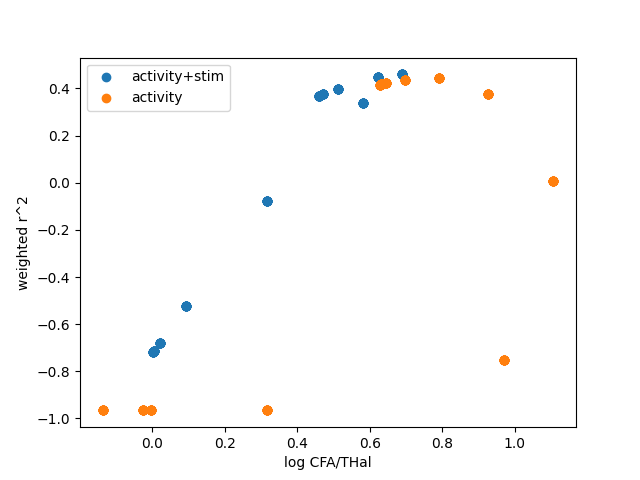

In [49]:
fig, ax = plt.subplots()
ax.scatter(ctrl_drives_all, ctrl_ar2_list, c='tab:blue', label='activity+stim')
ax.scatter(ctrl_drives_climb, ctrl_cr2_list, c='tab:orange', label='activity')
ax.set_xlabel('log CFA/THal')
ax.set_ylabel('weighted r^2')
ax.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


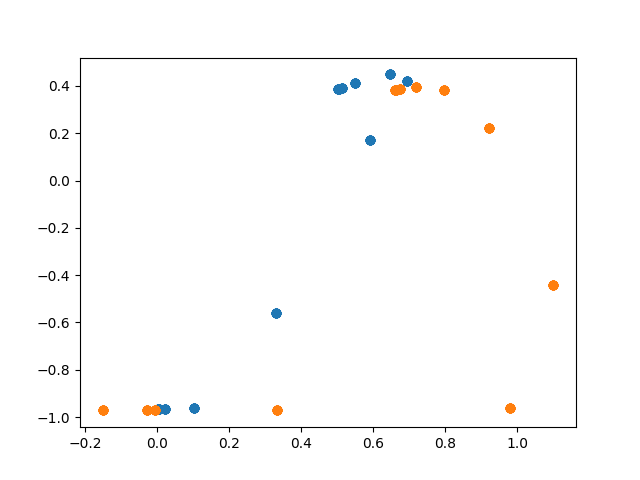

In [39]:
fig, ax = plt.subplots()
ax.scatter(laser_drives_all, laser_ar2_list)
ax.scatter(laser_drives_climb, laser_cr2_list)

In [40]:
ratio = np.array(ctrl_drives_all) 
r2s = np.array(ctrl_ar2_list)

c_ratio = np.array(ctrl_drives_climb) 
c_r2s = np.array(ctrl_cr2_list)

ratio_keep, r2_keep, _ = get_top_models(ratio, r2s, num_bins=11)
c_ratio_keep, c_r2_keep, _ = get_top_models(c_ratio, c_r2s, num_bins=11)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


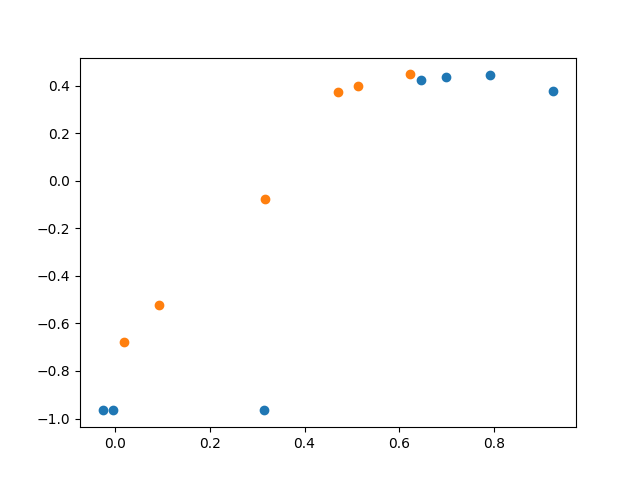

In [41]:
fig, ax = plt.subplots()
ax.scatter(c_ratio_keep, c_r2_keep)
ax.scatter(ratio_keep, r2_keep)

In [ ]:
session_path = '/home/diya/Documents/mp_opto/data/mp_record/mp32/mp32_04182023'
session = MPRecordClass(session_path)

mp32_04182023 successfulyl loaded


In [163]:
binsize=5
nlags=20
num_PCs=20
X, Y, PCs = session.generate_trainset(session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)

In [126]:
cfa_mask, thal_mask = session.mask_input_region(X, nlags, num_CFA=num_PCs)
X_cfa = X[:,cfa_mask]

In [127]:
X_cfa.shape

(82396, 400)

In [129]:
y, yhat, h = wiener_kfolds(X, Y, c=(2,5))

4it [00:37,  9.27s/it]


In [130]:
y2, yhat2, h2 = wiener_kfolds(X_cfa, Y, c=(2,5))

4it [00:13,  3.27s/it]


In [131]:
print(weighted_r2(y, yhat))
print(weighted_r2(y2, yhat2))

0.16970998069903448
0.1735851407462055


In [25]:
varz = np.var(laser_aX[:,:20], axis=0) / np.var(laser_aX)

In [26]:
percent_change_list = []
for idx in range(len(h_all_list)):
    h_all = h_all_list[idx]
    h_climb = h_climb_list[idx]
    if ctrl_ar2_list[idx] < 0:
        continue
    if ctrl_cr2_list[idx] < 0:
        continue
    print('good!')
    h_all_col = collapse_h(h_all, varz, nlags=20, num_CFA=num_CFA)
    h_climb_col = collapse_h(h_climb, varz, nlags=20, num_CFA=num_CFA)
    
    percent_change_list.append(h_all_col/h_climb_col * 100)

good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!
good!


In [27]:

check = np.array(percent_change_list)

In [28]:
stdz = np.std(check, axis=0)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

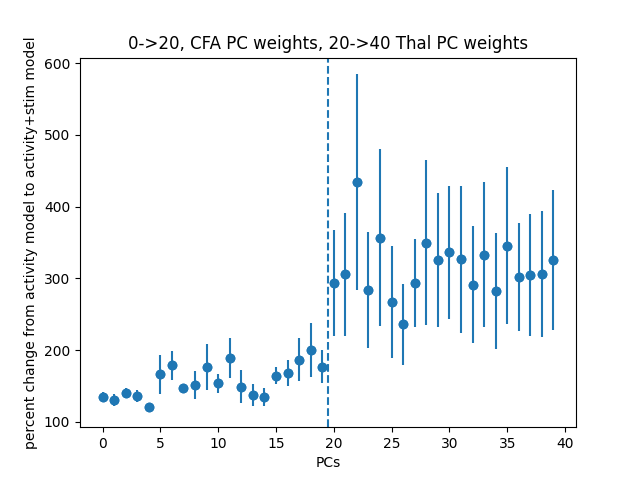

In [30]:
fig, ax = plt.subplots()
ax.scatter(np.arange(40), np.average(check, axis=0))
ax.errorbar(np.arange(40), np.average(check, axis=0), yerr=stdz, fmt="o")
ax.axvline(19.5, linestyle='--')
ax.set_ylabel('percent change from activity model to activity+stim model')
ax.set_title('0->20, CFA PC weights, 20->40 Thal PC weights')
ax.set_xlabel('PCs')